In [ ]:
%load_ext autoreload
%autoreload 2 
import numpy as np 
import shap
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import root_mean_squared_error
from Preprocess import preprocess_data
from xgboost import XGBRegressor
from xgboost.callback import EarlyStopping
from sklearn.metrics import mean_absolute_error
import optuna

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [14]:
data = pd.read_csv("../Whillians-GPS-Data-and-Features.csv")
X_train, X_val, X_test, y_train, y_val, y_test, feature_cols = preprocess_data(data)

In [15]:
# XGBoost


#Tuning XGBoost through the Optuna library
def objective(trial):
  XGBoost = XGBRegressor(
      objective="reg:squarederror",
      n_estimators=1000,
      learning_rate=trial.suggest_float("learning_rate", 0.01, 0.1, log=True), #sweeping 0.01 to 0.1 in the log scale for optimal learning rate
      max_depth=trial.suggest_int("max_depth",2,5), #checking max depth between 2 and 5
      subsample=trial.suggest_float("subsample",0.6,0.9), #sweeping subsample possibilites between 0.6 and 0.9
      colsample_bytree=trial.suggest_float("colsample_bytree",0.6,0.9), #sweeping bytree parameters between 0.6 and 0.9
      random_state=42
  )
  XGBoost.fit(
      X_train, y_train, eval_set=[(X_val, y_val)], verbose=False) #To see more model info set verbose=True
  predictions= XGBoost.predict(X_val)
  RMSE = root_mean_squared_error(y_val, predictions)
  return RMSE

optimization = optuna.create_study(direction="minimize") #Finding the parameters that minimize the MAE
optimization.optimize(objective, n_trials=30) #Keeping at 30 to prevent overfitting with noise

#Showing what the parameters are
optimal_params = optimization.best_params
print("Optimal Parameters:", optimal_params)

#Running the XGBoost with the optimal parameters
XGBoost = XGBRegressor(
    objective="reg:squarederror",
    n_estimators=1000,
    **optimal_params,
    random_state=42,
)

XGBoost.fit(
    X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)

#Calculating multiplicative error for XGBoost
XGBoost_Prediction = XGBoost.predict(X_test)
XGBoost_RMSE = root_mean_squared_error(y_test, XGBoost_Prediction)
XGBoost_Error = XGBoost_RMSE
print("XGBoost Error:", XGBoost_Error)

XGBoost_RMSE = mean_absolute_error(y_test, XGBoost_Prediction)
XGBoost_Error_MAE = XGBoost_RMSE
print("Mean XGBoost Error:", XGBoost_Error_MAE)

[I 2026-01-24 14:35:26,053] A new study created in memory with name: no-name-71121b7a-e334-4e6a-8992-6e13aef3b4af
[I 2026-01-24 14:35:26,750] Trial 0 finished with value: 10373.39651646902 and parameters: {'learning_rate': 0.01576219046990592, 'max_depth': 4, 'subsample': 0.8277444910941696, 'colsample_bytree': 0.6768985518575619}. Best is trial 0 with value: 10373.39651646902.
[I 2026-01-24 14:35:27,304] Trial 1 finished with value: 11193.553109723935 and parameters: {'learning_rate': 0.019926809202473892, 'max_depth': 4, 'subsample': 0.8870897173079794, 'colsample_bytree': 0.8664072875326695}. Best is trial 0 with value: 10373.39651646902.
[I 2026-01-24 14:35:27,729] Trial 2 finished with value: 9768.65501310012 and parameters: {'learning_rate': 0.03733502457806139, 'max_depth': 2, 'subsample': 0.6536360124041267, 'colsample_bytree': 0.7452507533876618}. Best is trial 2 with value: 9768.65501310012.
[I 2026-01-24 14:35:28,202] Trial 3 finished with value: 10985.520903598876 and param

Optimal Parameters: {'learning_rate': 0.01455483623923366, 'max_depth': 5, 'subsample': 0.6727314875186429, 'colsample_bytree': 0.6027580693119028}
XGBoost Error: 3387.5494651775
Mean XGBoost Error: 873.6405047605448


Sample0: True = 665.00s, Predicted = 857.07s, Error=192.07s
Sample1: True = 897.75s, Predicted = 892.87s, Error=4.88s
Sample2: True = 1377.25s, Predicted = 842.26s, Error=534.99s
Sample3: True = 1545.00s, Predicted = 703.05s, Error=841.95s
Sample4: True = 1230.00s, Predicted = 907.88s, Error=322.12s
Sample5: True = 803.75s, Predicted = 947.84s, Error=144.09s
Sample6: True = 790.00s, Predicted = 1038.15s, Error=248.15s
Sample7: True = 1196.25s, Predicted = 1066.76s, Error=129.49s
Sample8: True = 920.00s, Predicted = 853.37s, Error=66.63s
Sample9: True = 715.00s, Predicted = 945.05s, Error=230.05s
Sample10: True = 1223.75s, Predicted = 1021.43s, Error=202.32s
Sample11: True = 1396.25s, Predicted = 974.81s, Error=421.44s
Sample12: True = 1448.75s, Predicted = 1048.28s, Error=400.47s
Sample13: True = 1446.25s, Predicted = 925.68s, Error=520.57s
Sample14: True = 1505.00s, Predicted = 1042.84s, Error=462.16s
Sample15: True = 615.00s, Predicted = 1138.27s, Error=523.27s
Sample16: True = 868.7

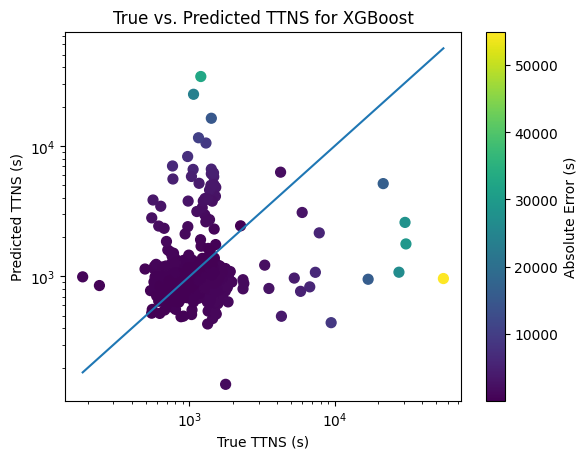

In [16]:
#XGBoost Analysis

#Taking the target column and predictions out of the log scale to calculate the average error in seconds
y_test_secs = y_test
XG_pred_secs = XGBoost_Prediction

absolute_error_secs_XG = np.abs(XG_pred_secs - y_test_secs)

#printing the true vs predicted value and error in seconds for every recrod
for i, (true, pred, abs_error) in enumerate(zip(y_test_secs, XG_pred_secs, absolute_error_secs_XG)):
  print(f"Sample{i}: True = {true:.2f}s, Predicted = {pred:.2f}s, Error={abs_error:.2f}s")

# Scatter plot of predicted vs true
plt.figure()
plt.scatter(y_test_secs, XG_pred_secs, c=absolute_error_secs_XG, cmap='viridis', s=50)
plt.colorbar(label="Absolute Error (s)")
plt.plot([min(y_test_secs), max(y_test_secs)], [min(y_test_secs), max(y_test_secs)])
plt.xlabel("True TTNS (s)")
plt.ylabel("Predicted TTNS (s)")
plt.title("True vs. Predicted TTNS for XGBoost")
plt.xscale('log')
plt.yscale('log')
plt.show()

 98%|===================| 757/773 [00:17<00:00]        

XG Boost Drivers: time_since     324.732798
slip_size      175.045897
form_fac       168.236910
tide_deriv     160.719309
tide_height    138.351345
high_t_evt      29.770112
dtype: float64


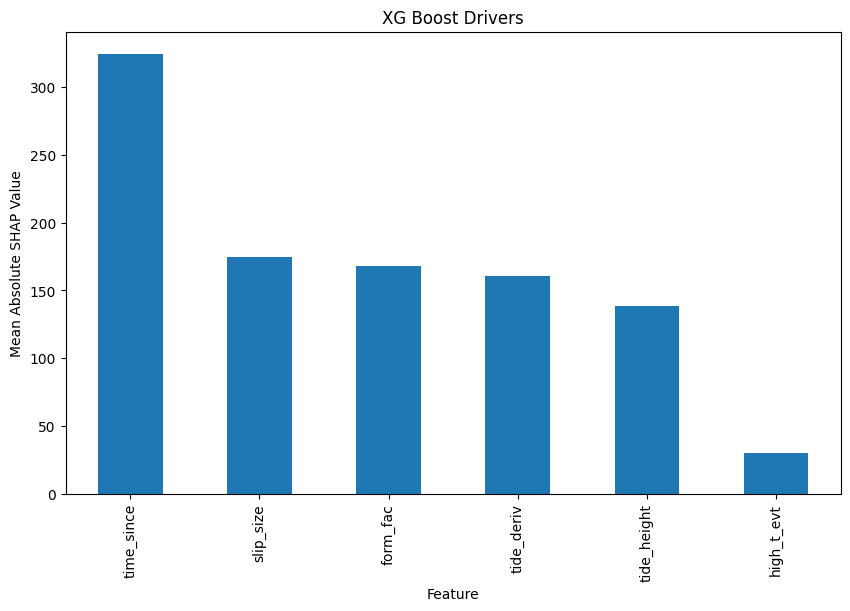

In [ ]:
# Driving parameters for XG 

#Using the shap library with a copy of the training data to find the driving parameters
X_shap = X_test.copy()
explainer_XG = shap.TreeExplainer(XGBoost, X_shap, feature_perturbation="interventional") #Using interventional to respect correlation between the features

shap_values_XG = explainer_XG.shap_values(X_shap) #Doing the tree analysis on XG using training data

XG_imp = pd.Series(np.abs(shap_values_XG).mean(axis=0), index=X_shap.columns).sort_values(ascending=False) #Analysis of driving parameters in XG

print("XG Boost Drivers:", XG_imp)

# Creating a bar graph showing the driving parameters for XGBoost 
plt.figure(figsize=(10, 6))
XG_imp.sort_values(ascending=False).plot(kind="bar")
plt.title("XG Boost Drivers")
plt.ylabel("Mean Absolute SHAP Value")
plt.xlabel("Feature")
plt.show()
